In [29]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet, RidgeCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor

In [30]:
df = pd.read_csv(r'data/diamonds.csv')

print('shape:', df.shape)
display(df.head())

shape: (53940, 11)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [31]:
X = df.drop(columns=['Unnamed: 0', 'price'])
y = df['price']
print('X shape:', X.shape)

X shape: (53940, 9)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('X train columns:', X_train.columns.tolist())

Train shape: (43152, 9)
Test shape: (10788, 9)
X train columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


In [33]:
# preprocessing pipeline
def make_preprocessor(X_data):
    num_cols = X_data.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_data.select_dtypes(include=['str']).columns

    num_pipline = Pipeline(steps=[('scaler', StandardScaler())])

    cat_pipeline = Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore')), ('scaler', StandardScaler(with_mean=False))])

    # column transformer - allows for different pipelines for different columns
    preprocessor = ColumnTransformer(transformers=[('num', num_pipline, num_cols), ('cat', cat_pipeline, cat_cols)])

    return preprocessor

preprocessor = make_preprocessor(X_train)

In [34]:
y_std = y_train.std()
print('y std:', y_std)

y std: 3990.000961768729


In [35]:
# model pipeline
def make_pipeline(model):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    return pipeline

# grouping models and their hyperparameters for grid search
configs = {
    'ElasticNet': {'pipeline': make_pipeline(ElasticNet(random_state=42)), 
                   'params': {'model__alpha': (1, 3, 5), 'model__l1_ratio': np.linspace(0, 1, 20)}},
    

    'LinearSVR': {'pipeline': make_pipeline(LinearSVR(random_state=42, max_iter=5000)), 
            'params': {'model__C': [1000], 'model__epsilon': [0.05* y_std, 0.1* y_std], 
                       'model__loss': ['epsilon_insensitive', 'squared_epsilon_insensitive']}},
    

    'KNN': {'pipeline': make_pipeline(KNeighborsRegressor(p = 1, n_jobs=1, algorithm='ball_tree')), # manhattan distance (p=1)
            'params': {'model__n_neighbors': [11, 31, 51], 'model__weights': ['uniform', 'distance']}},
    

    'XGBoost': {'pipeline': make_pipeline(XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=400, learning_rate=0.05)), 
                'params': { 'model__max_depth': [7, 10], 'model__subsample': [.7, .8, .9],
                           'model__min_child_weight': [1,3,5], 'model__colsample_bytree': [0.8]}},
    }

1st gridsearch- 

1. elastic net - makes it lasso
2. linear svr - C: 100 and epsilon: 0.3 * y_std
-- interrupted runtime to tune 
- added loss function to linear svr and increased C values and added scaler to cat pipeline

2nd gridsearch -
1. linearsvr upper limit (1000) and lower limit (0.1) and Squared epsilon insensitive - changing to [1000] (locking C to prevent overfitting) and epsilon to [0.05 * y_std, 0.1* y_std] to test

2. KNN lower limit (201) - lowering to [51, 101, 151]

3rd gridsearch -
1. Elastic net - 
    alpha: lower limit of 1 - changing to [1, 3, 5]
    
    l1_ratio: upper limit of 1 - locking 1 -> makes it lasso
1. KNN - lower limit of n_neighbors (51) - changing to [11, 31, 51]
2. XGBoost - 
    
    max_depth: upper limit (7) - changing to [7, 10]
    
    colsample_bytree: likes 0.8 (locking)
    
    min_child_weight: lower limit of 0.3 - changing to [1,3,5] to prevent overfitting
    
    subsample: upper limit of 0.7 - changing to [.7, .8, .9] to prevent overfitting

In [36]:
# grid search for each model
def tune_gridsearch(model_name, pipeline, params, X_data, y_data):
    print (f'Tuning {model_name}...')

    gs = GridSearchCV(estimator=pipeline, param_grid=params, cv=5, n_jobs=-1, verbose=1, scoring='neg_root_mean_squared_error')

    gs.fit(X_data, y_data)

    print(f'Best params for {model_name}:', gs.best_params_)
    print(f'Best score for {model_name}:', -gs.best_score_)
    
    return gs

gridsearch_results = {}
for model_name, config in configs.items():
    gridsearch_results[model_name] = tune_gridsearch(model_name, config['pipeline'], config['params'], X_train, y_train)

Tuning ElasticNet...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params for ElasticNet: {'model__alpha': 1, 'model__l1_ratio': np.float64(1.0)}
Best score for ElasticNet: 1129.9693298388443
Tuning LinearSVR...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params for LinearSVR: {'model__C': 1000, 'model__epsilon': np.float64(199.50004808843647), 'model__loss': 'squared_epsilon_insensitive'}
Best score for LinearSVR: 1132.3443366173592
Tuning KNN...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params for KNN: {'model__n_neighbors': 11, 'model__weights': 'distance'}
Best score for KNN: 737.6026777868743
Tuning XGBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for XGBoost: {'model__colsample_bytree': 0.8, 'model__max_depth': 7, 'model__min_child_weight': 3, 'model__subsample': 0.9}
Best score for XGBoost: 546.0401977539062


In [37]:
# xgb early stopping
# use the best params from grid search then tune for learning rate and n_estimators

xgb_best_params_gs = gridsearch_results['XGBoost'].best_params_
xgb_best_params = {}
for param, value in xgb_best_params_gs.items():
    new_param = param.split('model__')[1]
    xgb_best_params[new_param] = value

X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

xgb_preprocessor = make_preprocessor(X_train) # makes preprocessor object
X_xgb_train_proc = xgb_preprocessor.fit_transform(X_xgb_train) # learns proc steps + applies to train
X_xgb_val_proc = xgb_preprocessor.transform(X_xgb_val) # applies proc steps to val (does not learn from val)

xgb_es_model = XGBRegressor(objective='reg:squarederror', random_state=42, **xgb_best_params)

lr_prams = [0.001, 0.005, 0.01]
result = []

for lr in lr_prams:
    model = XGBRegressor(objective='reg:squarederror', random_state=42, learning_rate=lr, n_estimators=2000, 
                         early_stopping_rounds=400, n_jobs=-1, **xgb_best_params)
    model.fit(X_xgb_train_proc, y_xgb_train, eval_set=[(X_xgb_val_proc, y_xgb_val)], verbose=False)

    pred_val = model.predict(X_xgb_val_proc)
    rmse = root_mean_squared_error(y_xgb_val, pred_val)
    best_iter = model.best_iteration
    result.append((lr, rmse, best_iter))

print('learning_rate, rmse, best_iter')
for lr, rmse, best_iter in result:
    print(lr, rmse, best_iter)

best_lr, best_rmse, best_iter = min(result, key=lambda x: x[1])
best_round = best_iter + 1
print('best model:', best_lr, best_rmse, best_iter)

xgbr_final = make_pipeline(XGBRegressor(objective='reg:squarederror', random_state=42, learning_rate=best_lr, 
                                        n_estimators=best_round, n_jobs=-1, **xgb_best_params))

xgbr_final = xgbr_final.fit(X_train, y_train)


learning_rate, rmse, best_iter
0.001 894.71337890625 1999
0.005 544.2949829101562 1998
0.01 539.96826171875 1742
best model: 0.01 539.96826171875 1742


1st Iteration: Learning rate - lower bound of 0.01 - changing to [0.001, 0.005, 0.01]

In [38]:
# final models
final_models = {'ElasticNet': gridsearch_results['ElasticNet'].best_estimator_,
                'LinearSVR': gridsearch_results['LinearSVR'].best_estimator_,
                'KNN': gridsearch_results['KNN'].best_estimator_,
                'XGBoost': xgbr_final}

In [39]:
# Ensemble model - stacking
stacking_model = StackingRegressor(estimators = [('enet', (final_models['ElasticNet'])), ('svr', (final_models['LinearSVR'])),
                                                 ('knn', (final_models['KNN'])), ('xgb', (final_models['XGBoost']))],
                                                final_estimator=RidgeCV(), cv=5, n_jobs=-1)
stacking_model.fit(X_train, y_train)
final_models['Stacking'] = stacking_model

In [40]:
# eval for each model
def eval_model(name, model, X_data, y_data):
    pred = model.predict(X_data)
    mae = mean_absolute_error(y_data, pred)
    rmse = root_mean_squared_error(y_data, pred)
    r2 = r2_score(y_data, pred)
    return {'model': name, 'mae': mae, 'rmse': rmse, 'r2': r2}

rows = []
for name, model in final_models.items():
    rows.append(eval_model(name, model, X_test, y_test))

results_df = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
display(results_df)

,model,mae,rmse,r2
0,Stacking,269.455546,531.743517,0.982213
1,XGBoost,271.029907,535.156738,0.981984
2,KNN,338.960898,675.124464,0.971328
3,ElasticNet,737.842726,1135.093528,0.918950
4,LinearSVR,762.560258,1138.503934,0.918462


In [44]:
# numeric feature importance output from the trained Stacking model
from sklearn.inspection import permutation_importance

stack_model = final_models.get('Stacking', stacking_model)
perm_result = permutation_importance(
    stack_model,
    X_test,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
 )

feature_importance_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )

display(feature_importance_df)

,feature,importance,importance_std
0,carat,3339.956909,16.158881
1,y,1468.471681,7.418735
2,clarity,1101.310135,11.395731
3,color,765.001176,11.759057
4,x,122.668438,1.185919
5,z,112.780385,1.642899
6,cut,33.844147,2.064112
7,depth,12.530547,2.514405
8,table,8.454496,1.421175


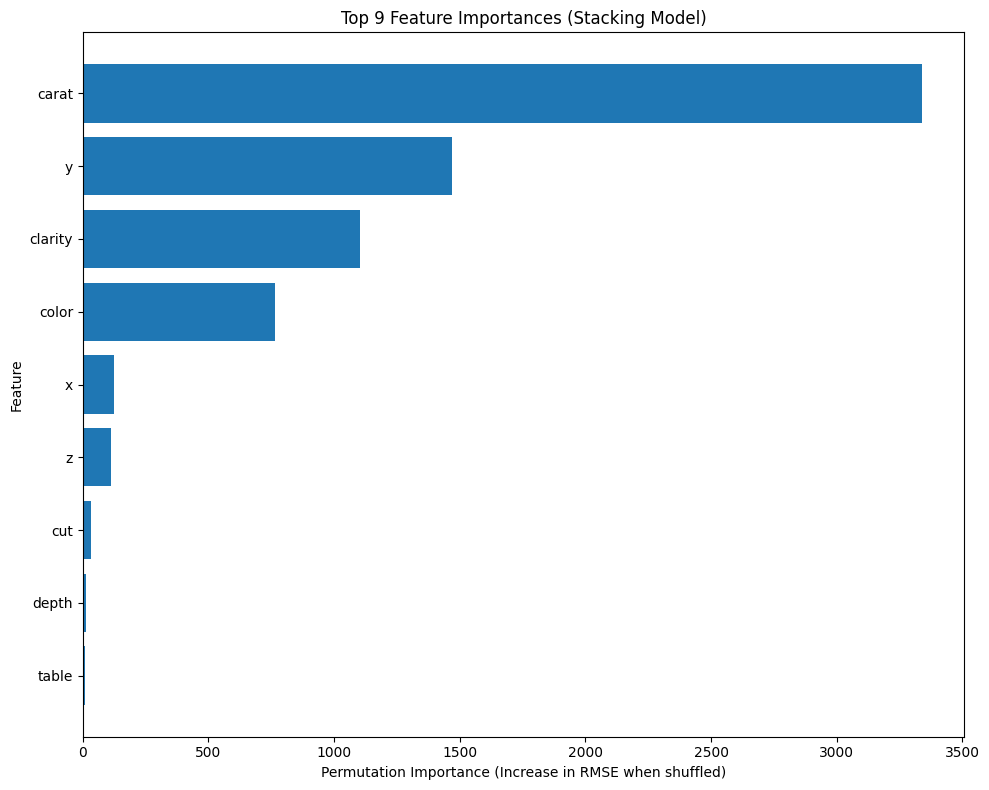

In [45]:
import matplotlib.pyplot as plt

top_n = min(20, len(feature_importance_df))
fi_plot = feature_importance_df.head(top_n).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_plot['feature'], fi_plot['importance'])
plt.xlabel('Permutation Importance (Increase in RMSE when shuffled)')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances (Stacking Model)')
plt.tight_layout()
plt.show()